In [7]:
# param2field_train_regularized.py
import os, math, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from typing import Optional, Tuple, Literal
from tqdm import tqdm
import sys
from typing import Tuple, Optional, Literal
import torch
import torch.nn as nn

sys.path.append("../../")
sys.path.append("../")
sys.path.append("./")
sys.path.append("/")


from models.Okada_UFNO import *

In [8]:
def update_loss_plot(history, plot_every: int = 5, force: bool = False):
    """
    Live-update training/validation loss curves in a Jupyter notebook (log-scale y-axis).

    Args:
        history: dict with keys "train" and "val", each a list of floats
        plot_every: refresh the plot every N epochs (unless force=True)
        force: force a refresh (e.g., final update after training)
    """
    n = len(history.get("train", []))
    if not force and (n % max(1, plot_every) != 0):
        return

    try:
        from IPython.display import clear_output, display
    except Exception:
        clear_output = None
        display = None
    import matplotlib.pyplot as plt

    tr = history.get("train", [])
    va = history.get("val", [])
    xs = list(range(1, len(tr) + 1))

    if not hasattr(update_loss_plot, "_fig") or update_loss_plot._fig is None:
        update_loss_plot._fig, update_loss_plot._ax = plt.subplots(figsize=(7, 4.5))
    fig, ax = update_loss_plot._fig, update_loss_plot._ax

    ax.cla()
    ax.plot(xs, tr, label="train loss", linewidth=2)
    if len(va) == len(tr):
        ax.plot(xs, va, label="val loss", linewidth=2)
    elif len(va) > 0:
        ax.plot(range(1, len(va) + 1), va, label="val loss", linewidth=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    ax.set_yscale("log")
    ax.set_title("Training / Validation Loss (Log Scale)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()

    if clear_output and display:
        clear_output(wait=True)
        display(fig)
    else:
        fig.canvas.draw_idle()
        plt.pause(0.001)


In [9]:
def set_seed(s):
    random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def mae(x, y):  return torch.mean(torch.abs(x - y))
def rmse(x, y): return torch.sqrt(torch.mean((x - y)**2))

def print_range(name, t):
    tmin = float(t.min()); tmax = float(t.max()); tmean= float(t.mean()); tstd = float(t.std())
    print(f"{name}: min={tmin:.4g} max={tmax:.4g} mean={tmean:.4g} std={tstd:.4g}")

@torch.no_grad()
def total_variation(x):
    # x: [B,1,H,W]
    dx = torch.abs(x[..., 1:, :] - x[..., :-1, :]).mean()
    dy = torch.abs(x[..., :, 1:] - x[..., :, :-1]).mean()
    return dx + dy



In [10]:
# ----------------------- DATA / NORM ------------------------
def load_tensors(path, path_initial):
    blob = torch.load(path, weights_only=False)
    initial_dataset = torch.load(path_initial, weights_only=False)
    initial_stage = torch.tensor(initial_dataset).unsqueeze(0)

    add_initial = True
    Xp, Yf = blob.tensors          # Xp: [N, n_parameters], Yf: [N, nx, ny]
    initial_stage = initial_stage.repeat(Yf.shape[0], 1, 1)
    if add_initial:
        Yf = Yf +  initial_stage

    # else:
    #     Xp, Yf = blob["X"], blob["Y"]
    assert Xp.ndim == 2 and Xp.shape[1] == n_parameters, f"X must be [N,{n_parameters}]"
    assert Yf.ndim == 3 and Yf.shape[1:] == (nx, ny), f"Y must be [N,{nx},{ny}]"
    assert torch.isfinite(Xp).all(), "X has NaN/Inf"
    assert torch.isfinite(Yf).all(), "Y has NaN/Inf"
    Xp, Yf = Xp.float(), Yf.float()
    return Xp, Yf  # X_params, Y_field


class NormWrap(torch.utils.data.Dataset):
    """
    Wraps tensors and applies normalization depending on MODEL_DIRECTION:

    - forward:  x = (params - x_mu)/x_std       -> shape [n_parameters]
                y = (field  - y_mu)/y_std       -> shape [1, nx, ny]
    - inverse:  x = (field  - x_mu)/x_std       -> shape [1, nx, ny]
                y = (params - y_mu)/y_std       -> shape [n_parameters]
    """
    def __init__(self, X_params, Y_field, x_mu, x_std, y_mu, y_std):
        self.Xp, self.Yf = X_params, Y_field
        self.x_mu, self.x_std = x_mu, x_std
        self.y_mu, self.y_std = y_mu, y_std

    def __len__(self): return self.Xp.shape[0]

    def __getitem__(self, i):
        if MODEL_DIRECTION == "forward":
            x = (self.Xp[i] - self.x_mu) / self.x_std                     # [n_parameters]
            y = (self.Yf[i] - self.y_mu) / self.y_std                     # [nx, ny]
            y = y.unsqueeze(0)                                            # [1, nx, ny]
            return x, y
        else:  # "inverse"
            x = (self.Yf[i] - self.x_mu) / self.x_std                     # [nx, ny]
            x = x.unsqueeze(0)                                            # [1, nx, ny]
            y = (self.Xp[i] - self.y_mu) / self.y_std                     # [n_parameters]
            return x, y


def make_splits_normed(path, path_initial, split=(0.8,0.1,0.1), seed=1337):
    Xp, Yf = load_tensors(path, path_initial)
    print("Loaded:")
    print_range("Params (X)", Xp)
    print_range("Field  (Y)", Yf)

    N = len(Xp)
    n_tr = int(N*split[0]); n_va = int(N*split[1]); n_te = N - n_tr - n_va
    g = torch.Generator().manual_seed(seed)
    ds_full = TensorDataset(Xp, Yf)
    ds_tr_raw, ds_va_raw, ds_te_raw = random_split(ds_full, [n_tr, n_va, n_te], generator=g)

    Xtr = ds_tr_raw.dataset.tensors[0][ds_tr_raw.indices]
    Ytr = ds_tr_raw.dataset.tensors[1][ds_tr_raw.indices]

    eps = 1e-6
    if MODEL_DIRECTION == "forward":
        # x = params (per-feature stats), y = field (scalar stats)
        x_mu  = Xtr.mean(0)                           # [n_parameters]
        x_std = Xtr.std(0).clamp_min(eps)             # [n_parameters]
        y_mu  = Ytr.mean()                             # scalar
        y_std = Ytr.std().clamp_min(eps)              # scalar
    else:  # "inverse"
        # x = field (scalar stats), y = params (per-feature stats)
        x_mu  = Ytr.mean()                             # scalar
        x_std = Ytr.std().clamp_min(eps)              # scalar
        y_mu  = Xtr.mean(0)                           # [n_parameters]
        y_std = Xtr.std(0).clamp_min(eps)             # [n_parameters]

    ds_tr = NormWrap(ds_tr_raw.dataset.tensors[0][ds_tr_raw.indices],
                     ds_tr_raw.dataset.tensors[1][ds_tr_raw.indices],
                     x_mu, x_std, y_mu, y_std)
    ds_va = NormWrap(ds_va_raw.dataset.tensors[0][ds_va_raw.indices],
                     ds_va_raw.dataset.tensors[1][ds_va_raw.indices],
                     x_mu, x_std, y_mu, y_std)
    ds_te = NormWrap(ds_te_raw.dataset.tensors[0][ds_te_raw.indices],
                     ds_te_raw.dataset.tensors[1][ds_te_raw.indices],
                     x_mu, x_std, y_mu, y_std)

    def _fmt(t):
        if torch.is_tensor(t) and t.ndim > 0: return f"mean~{float(t.mean()):.3g}"
        return f"{float(t):.3g}"

    print(f"Stats ({MODEL_DIRECTION}): x_mu={_fmt(x_mu)}, x_std={_fmt(x_std)}, y_mu={_fmt(y_mu)}, y_std={_fmt(y_std)}")
    stats = dict(x_mu=x_mu, x_std=x_std, y_mu=y_mu, y_std=y_std)
    return ds_tr, ds_va, ds_te, stats


def make_loaders(ds_tr, ds_va, ds_te):
    train_loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(ds_va, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(ds_te, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader


# ----------------------- TRAIN / EVAL -----------------------
data_loss = nn.SmoothL1Loss(beta=0.01)  # Huber

def train_one_epoch(model, loader, opt, scaler, y_mu, y_std, use_amp=False,
                    input_noise_std=0.0, tv_lambda=0.0):
    """
    - forward mode : model(X:[B,n_params]) -> pred_norm:[B,1,H,W], compare to Y:[B,1,H,W]
    - inverse mode : model(X:[B,1,H,W])    -> pred_norm:[B,n_params], compare to Y:[B,n_params]
    """
    model.train()
    running = 0.0; n = 0
    for X, Y in tqdm(loader, desc="train", leave=False):
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)

        if use_amp and device == "cuda":
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                if MODEL_DIRECTION == "forward":
                    pred_norm = model(X, add_input_noise_std=input_noise_std)      # [B,1,H,W]
                    loss = data_loss(pred_norm, Y)                                 # Y is [B,1,H,W]
                    if tv_lambda > 0:
                        # TV on ORIGINAL field scale
                        pred_orig = pred_norm * y_std + y_mu
                        loss = loss + tv_lambda * total_variation(pred_orig)
                else:
                    pred_norm = model(X, add_input_noise_std=0.0)                  # [B,n_params]
                    loss = data_loss(pred_norm, Y)                                 # Y is [B,n_params]
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        else:
            if MODEL_DIRECTION == "forward":
                pred_norm = model(X, add_input_noise_std=input_noise_std)          # [B,1,H,W]
                loss = data_loss(pred_norm, Y)
                if tv_lambda > 0:
                    pred_orig = pred_norm * y_std + y_mu
                    loss = loss + tv_lambda * total_variation(pred_orig)
            else:
                pred_norm = model(X, add_input_noise_std=0.0)                      # [B,n_params]
                loss = data_loss(pred_norm, Y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        if not math.isfinite(loss.item()):
            raise RuntimeError("Loss NaN/Inf. Reduce lr/disable AMP/check data.")
        running += loss.item() * X.size(0); n += X.size(0)
    return running / n


@torch.no_grad()
def eval_epoch(model, loader, y_mu: torch.Tensor, y_std: torch.Tensor):
    """
    Returns:
      - forward: loss (norm), MAE/RMSE in ORIGINAL FIELD units
      - inverse: loss (norm), MAE/RMSE in ORIGINAL PARAM units
    """
    model.eval()
    totL=totMAE=totRMSE=0.0; n=0
    for X, Y in tqdm(loader, desc="eval", leave=False):
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)

        if MODEL_DIRECTION == "forward":
            pred_norm = model(X, add_input_noise_std=0.0)          # [B,1,H,W]
            L = data_loss(pred_norm, Y)
            # de-normalize field for metrics
            pred = pred_norm * y_std + y_mu                        # scalar y_mu/y_std broadcast
            y_gt = Y * y_std + y_mu
        else:
            pred_norm = model(X, add_input_noise_std=0.0)          # [B,n_params]
            L = data_loss(pred_norm, Y)
            # de-normalize params for metrics (per-feature)
            pred = pred_norm * y_std + y_mu                        # vector y_mu/y_std
            y_gt = Y * y_std + y_mu

        totL     += L.item() * X.size(0)
        totMAE   += mae(pred, y_gt).item() * X.size(0)
        totRMSE  += rmse(pred, y_gt).item() * X.size(0)
        n += X.size(0)
    return totL/n, totMAE/n, totRMSE/n


def main():
    set_seed(seed)
    ds_tr, ds_va, ds_te, stats = make_splits_normed(DATA_PATH, INITAL_PATH, seed=seed)
    train_loader, val_loader, test_loader = make_loaders(ds_tr, ds_va, ds_te)

    model = Param2FieldDecoder128(
        n_parameters=n_parameters,
        start_hw=start_hw,
        n_stages=n_stages,
        base_ch=base_ch,
        ch_growth=ch_growth,
        n_convs_per_stage=n_convs_per_stage,
        up_method=up_method,
        norm=norm_type,
        act=act_type,
        residual=residual,
        out_channels=out_channels,
        target_hw=(nx, ny),
        proj_dropout_p=proj_dropout_p,
        block_dropout_p=block_dropout_p,
    ).to(device)

    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.9, patience=8)
    scaler = torch.amp.GradScaler('cuda', enabled=(use_amp and device=='cuda'))

    # SWA
    if use_swa:
        swa_model = torch.optim.swa_utils.AveragedModel(model)
        swa_sched = torch.optim.swa_utils.SWALR(opt, swa_lr=swa_lr)
    else:
        swa_model = None
        swa_sched = None

    best_val = float("inf")
    patience_left = patience

    # history for plotting
    history = {"train": [], "val": []}
    plot_every = 5

    # Stats to device (shape depends on direction)
    y_mu  = stats["y_mu"].to(device)
    y_std = stats["y_std"].to(device)

    for epoch in range(1, max_epochs+1):
        tr_loss = train_one_epoch(
            model, train_loader, opt, scaler,
            y_mu, y_std, use_amp=use_amp,
            input_noise_std=input_noise_std,
            tv_lambda=(tv_lambda if MODEL_DIRECTION == "forward" else 0.0)
        )
        val_loss, val_mae, val_rmse = eval_epoch(model, val_loader, y_mu, y_std)

        if use_swa and epoch >= swa_start_epoch:
            swa_model.update_parameters(model)
            swa_sched.step()
        else:
            sched.step(val_loss)

        history["train"].append(tr_loss)
        history["val"].append(val_loss)
        update_loss_plot(history, plot_every=plot_every, force=False)

        # Label metrics depending on direction
        unit = "FIELD" if MODEL_DIRECTION == "forward" else "PARAM"
        print(f"[{epoch:03d}] {MODEL_DIRECTION} | train={tr_loss:.6f} | val={val_loss:.6f} | "
              f"MAE({unit})={val_mae:.6f} | RMSE({unit})={val_rmse:.6f} | lr={opt.param_groups[0]['lr']:.2e}")

        torch.save({"model": model.state_dict(), "stats": stats}, last_path)

        if MODEL_DIRECTION == "forward":
            improved = math.isfinite(val_loss) and (val_loss < best_val - 1e-7)
        else:
            improved = math.isfinite(val_loss) and (val_loss < best_val - 1e-9)

        if improved:
            best_val = val_loss
            patience_left = patience
            torch.save({"model": model.state_dict(), "stats": stats}, best_path)
            print(f"  ✅ saved best to {best_path}")
        else:
            patience_left -= 1
            if patience_left == 0:
                print("  ⏹ early stopping")
                break

    update_loss_plot(history, plot_every=plot_every, force=True)

    # ----- Final eval: best, and SWA if enabled -----
    ckpt_path = best_path if os.path.exists(best_path) else last_path
    print(f"Loading BEST/LAST: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model"])
    y_mu  = ckpt["stats"]["y_mu"].to(device)
    y_std = ckpt["stats"]["y_std"].to(device)

    test_loss, test_mae, test_rmse = eval_epoch(model, test_loader, y_mu, y_std)
    unit = "FIELD" if MODEL_DIRECTION == "forward" else "PARAM"
    print(f"[BEST]  {MODEL_DIRECTION} | loss(norm)={test_loss:.6f} | MAE({unit})={test_mae:.6f} | RMSE({unit})={test_rmse:.6f}")

    if use_swa and 'swa_model' in locals() and swa_model is not None:
        torch.optim.swa_utils.update_bn(train_loader, swa_model, device=device)
        torch.save({"model": swa_model.module.state_dict(), "stats": stats}, swa_path)
        swa_loss, swa_mae, swa_rmse = eval_epoch(swa_model.module, test_loader, y_mu, y_std)
        print(f"[SWA ]  {MODEL_DIRECTION} | loss(norm)={swa_loss:.6f} | MAE({unit})={swa_mae:.6f} | RMSE({unit})={swa_rmse:.6f}")


In [11]:
# ------------------------- CONFIG -------------------------

# ----------------------- CONFIG: choose training direction -----------------------
# "forward": learn params -> field   (X = params, Y = field)
# "inverse": learn field  -> params  (X = field,  Y = params)
MODEL_DIRECTION = "forward"   # or "forward"

DATA_PATH   = "/storage/work/amb10399/project/SC-FNO-DIST/Tsunami/datasets/1000__3e5_8e5__2e5_8e5_with_jac_multi_fault/okada_fault.pt"
INITAL_PATH = '/storage/work/amb10399/project/SC-FNO-DIST/xTrash/initial_stage.pt'
seed        = 1337
device      = "cuda" if torch.cuda.is_available() else "cpu"
num_workers = 1
batch_size  = 16

# GENERALIZATION-FOCUSED HYPERPARAMS
lr               = 1e-3
weight_decay     = 5e-4      # stronger L2 than before
max_epochs       = 500
patience         = 100
use_amp          = False

# Regularizers (toggle these)
proj_dropout_p   = 0.2       # dropout right after projecting vector -> (C,H,W)
block_dropout_p  = 0.15      # spatial dropout inside conv blocks
input_noise_std  = 0.00      # Gaussian noise on input parameters during TRAIN only
tv_lambda        = 1e-4      # TV regularization strength on predictions (0 to disable)
label_smooth_eps = 0.0       # keep 0 (for regression; listed for completeness)

# SWA (stochastic weight averaging)
use_swa          = False
swa_start_epoch  = 120       # start SWA late
swa_lr           = 5e-4

# Shapes
n_parameters = 9
nx, ny       = 100, 100

# Decoder settings (smaller model to curb overfit)
start_hw             = (4, 4)
n_stages             = 5
base_ch              = 32      # was 64; smaller = less overfit
ch_growth            = 1.5     # was 2.0
n_convs_per_stage    = 1       # was 2; fewer layers
up_method            = "bilinear"
norm_type            = "in"
act_type             = "gelu"
residual             = False
out_channels         = 1

best_path = f"saved_models/param2field_best_{MODEL_DIRECTION}.pt"
last_path = f"saved_models/param2field_last_{MODEL_DIRECTION}.pt"
swa_path  = f"saved_models/param2field_swa_{MODEL_DIRECTION}.pt"


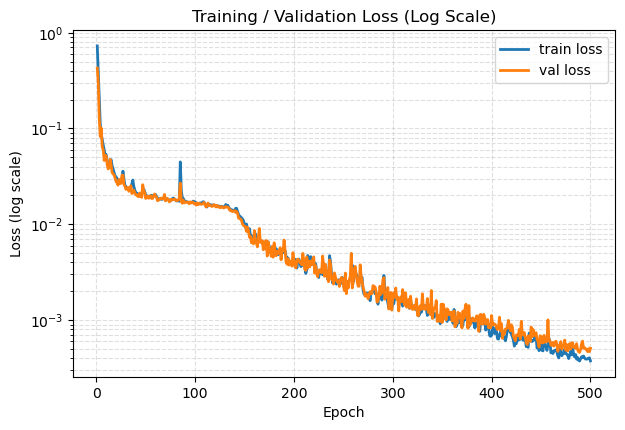

Loading BEST/LAST: saved_models/param2field_best_forward.pt


[BEST]  forward | loss(norm)=0.000550 | MAE(FIELD)=0.004010 | RMSE(FIELD)=0.024687


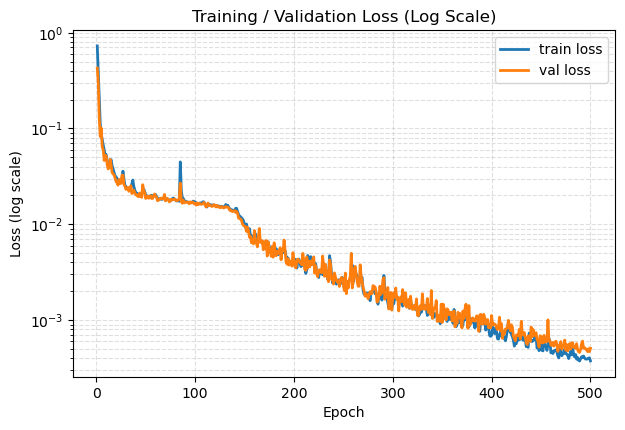

In [12]:
if __name__ == "__main__":
    main()


Loading checkpoint: saved_models/param2field_best_forward.pt
Loaded:
Params (X): min=0.02 max=7.993e+05 mean=1.482e+05 std=2.229e+05
Field  (Y): min=-4.693 max=13.91 mean=1.241 std=3.298
Stats (forward): x_mu=mean~1.48e+05, x_std=mean~4.46e+04, y_mu=1.24, y_std=3.3

=== Test set metrics ===
MSE (FIELD) : 0.000735
MAE (FIELD) : 0.004010
RMSE(FIELD) : 0.017260
R^2  (FIELD) : 0.999932
NSE : 0.999932
PSNR: 60.603 dB
True global range: [-4.6932, 11.9264]


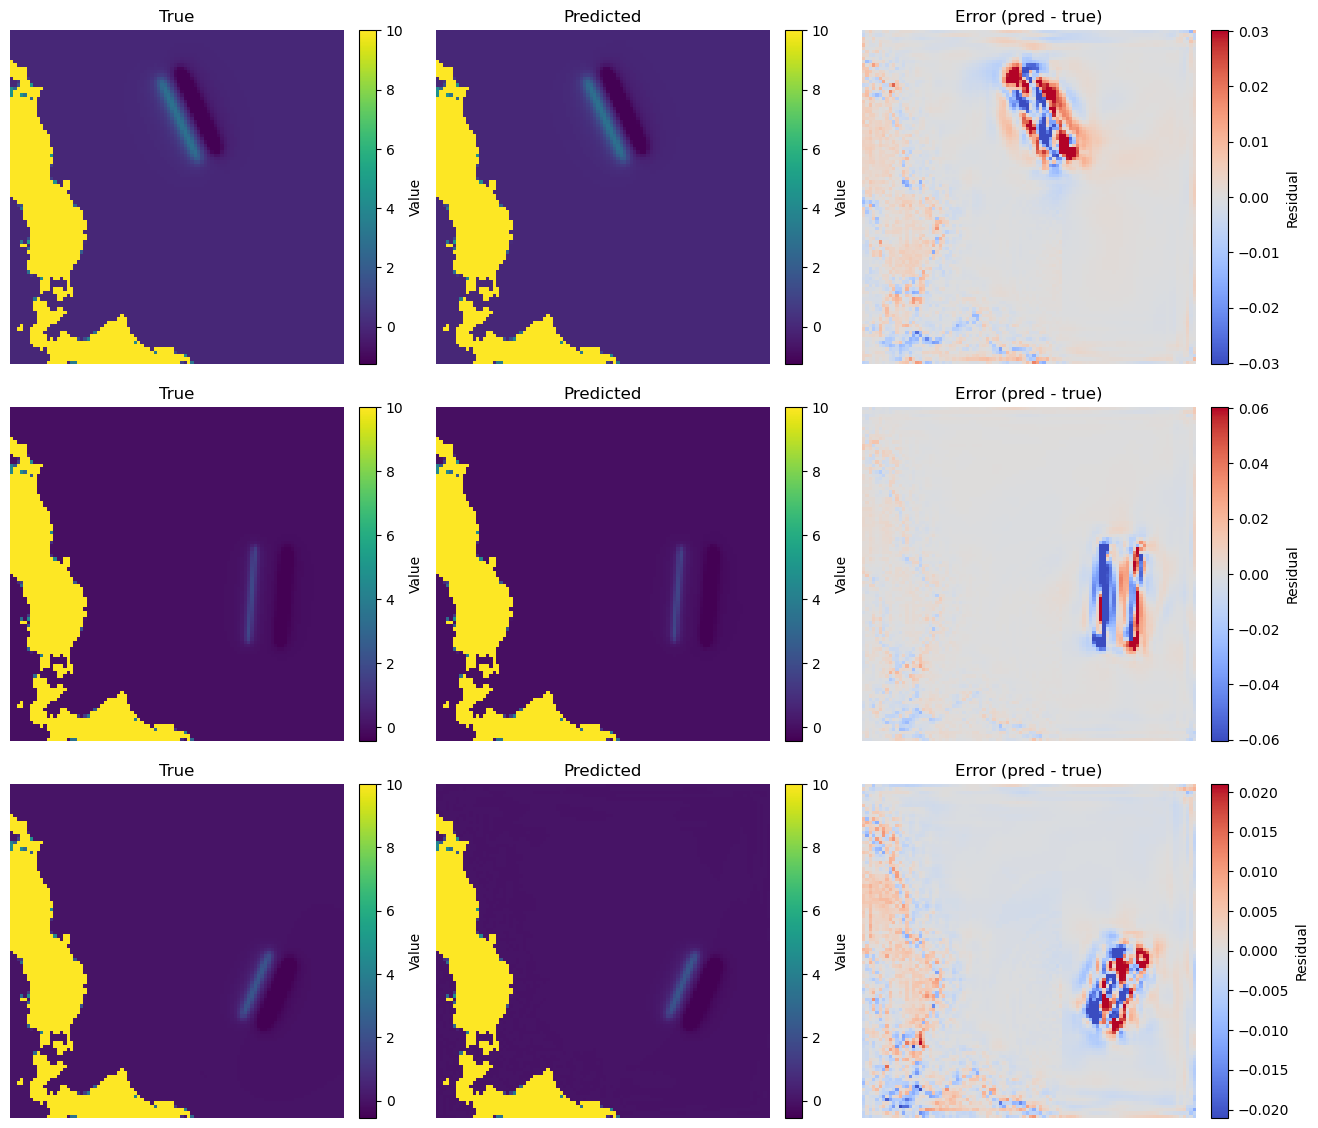

Saved: infer_vis/qualitative_panels.png


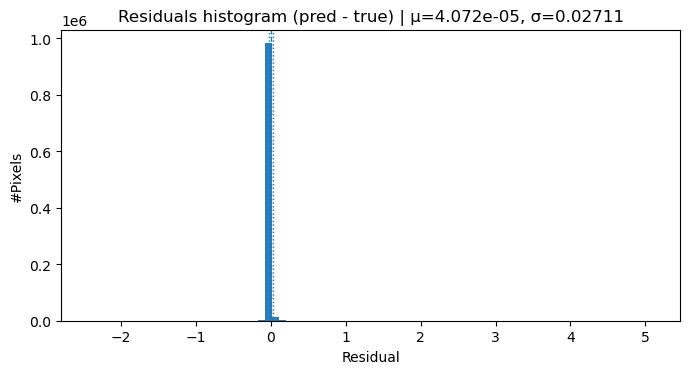

Saved: infer_vis/residual_hist.png


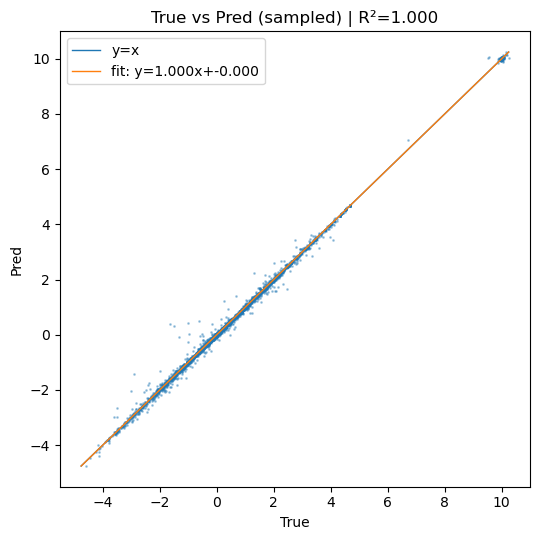

Saved: infer_vis/true_vs_pred_scatter.png


In [14]:
# param2field_infer.py
import os, math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from typing import Tuple

# from param2field_train import Param2FieldDecoder128, make_splits_normed, nx, ny, n_parameters, DATA_PATH, best_path, last_path, device

# ---- set this to the SAME value you used for training ("forward" or "inverse") ----

SAVE_DIR = "infer_vis"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------- helpers --------------------
def psnr_from_mse(mse: float, data_range: float) -> float:
    if mse <= 0 or data_range <= 0:
        return float("inf")
    return 20.0 * math.log10(data_range) - 10.0 * math.log10(mse)

def nse(true: torch.Tensor, pred: torch.Tensor) -> float:
    tbar = true.mean()
    num = torch.sum((true - pred) ** 2)
    den = torch.sum((true - tbar) ** 2).clamp_min(1e-12)
    return float(1.0 - (num / den))

def maybe_binary_mask(t: torch.Tensor, tol: float = 1e-3, min_ratio: float = 0.99) -> bool:
    if t.dim() == 4 and t.size(1) == 1:
        t = t[:,0]
    vals = t.reshape(t.size(0), -1)
    near01 = ((vals - 0.0).abs() < tol) | ((vals - 1.0).abs() < tol)
    ratio = near01.float().mean().item()
    return ratio >= min_ratio

def binary_metrics(pred: torch.Tensor, true: torch.Tensor, thr: float = 0.5):
    if pred.dim() == 4 and pred.size(1) == 1: pred = pred[:,0]
    if true.dim() == 4 and true.size(1) == 1: true = true[:,0]
    pred_b = (pred >= thr).float()
    true_b = (true >= thr).float()
    tp = (pred_b * true_b).sum().item()
    fp = (pred_b * (1 - true_b)).sum().item()
    fn = ((1 - pred_b) * true_b).sum().item()
    tn = (((1 - pred_b) * (1 - true_b))).sum().item()
    acc = (tp + tn) / max(tp + tn + fp + fn, 1e-8)
    iou = tp / max(tp + fp + fn, 1e-8)
    dice = (2 * tp) / max(2 * tp + fp + fn, 1e-8)
    return acc, iou, dice

def to_numpy_img(t: torch.Tensor):
    if t.dim() == 4 and t.size(1) == 1:
        t = t[0,0]
    elif t.dim() == 4:
        t = t[0].mean(0)
    return t.detach().cpu().numpy()

def robust_minmax(arr: np.ndarray, lo=1.0, hi=99.0):
    vmin = np.percentile(arr, lo)
    vmax = np.percentile(arr, hi)
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)

# -------------------- main --------------------
def main_eval():
    # ----------------- Load checkpoint -----------------
    ckpt_path = best_path if os.path.exists(best_path) else last_path
    print(f"Loading checkpoint: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)

    stats = ckpt["stats"]
    y_mu, y_std = stats["y_mu"].to(device), stats["y_std"].to(device)

    # ----------------- Rebuild model -----------------
    model = Param2FieldDecoder128(
        n_parameters=n_parameters,
        target_hw=(nx, ny),
    ).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()

    # ----------------- Data (normalized) -----------------
    ds_tr, ds_va, ds_te, _ = make_splits_normed(DATA_PATH, INITAL_PATH, seed=1337)
    test_loader = DataLoader(ds_te, batch_size=8, shuffle=False, num_workers=0)

    # ----------------- Evaluate whole test set -----------------
    per_sample = []
    all_err_flat = []
    ss_res, ss_tot = 0.0, 0.0
    all_psnr = []
    y_true_global_min, y_true_global_max = float("inf"), -float("inf")

    collect_true_for_bin = []
    collect_pred_for_bin = []

    with torch.no_grad():
        idx_base = 0
        for X, Y in test_loader:
            X = X.to(device).float()
            Y = Y.to(device).float()

            if MODEL_DIRECTION == "forward":
                # X: [B, n_params], Y: [B, 1, H, W] (already normalized by loader)
                pred_norm = model(X)
                pred = pred_norm * y_std + y_mu
                true = Y * y_std + y_mu

                err = pred - true
                B = X.size(0)

                mse_b = (err ** 2).mean(dim=(1,2,3))                # [B]
                mae_b = err.abs().mean(dim=(1,2,3))                 # [B]
                rmse_b = torch.sqrt(mse_b)                          # [B]

                tmin = true.amin(dim=(2,3), keepdim=True)
                tmax = true.amax(dim=(2,3), keepdim=True)
                dr = (tmax - tmin).clamp_min(1e-8)
                mse_map = (err ** 2).mean(dim=(2,3), keepdim=True)
                psnr_b = 20 * torch.log10(dr) - 10 * torch.log10(mse_map.clamp_min(1e-12))
                psnr_b = psnr_b.view(B)

                for i in range(B):
                    per_sample.append({
                        "index": idx_base + i,
                        "mse": float(mse_b[i].item()),
                        "mae": float(mae_b[i].item()),
                        "rmse": float(rmse_b[i].item()),
                        "psnr": float(psnr_b[i].item()),
                    })
                idx_base += B

                y_bar = true.mean(dim=(2,3), keepdim=True)
                ss_res += ((true - pred) ** 2).sum().item()
                ss_tot += ((true - y_bar) ** 2).sum().item()

                y_true_global_min = min(y_true_global_min, true.min().item())
                y_true_global_max = max(y_true_global_max, true.max().item())

                all_psnr += psnr_b.detach().cpu().tolist()
                all_err_flat.append(err.detach().cpu().numpy().ravel())

                collect_true_for_bin.append(true.detach().cpu())
                collect_pred_for_bin.append(pred.detach().cpu())

            else:  # INVERSE: X is field [B,1,H,W], Y is params [B,n_params]
                pred_norm = model(X)                                 # [B, n_params]
                pred = pred_norm * y_std + y_mu                      # denorm params
                true = Y * y_std + y_mu

                B = X.size(0)
                err = pred - true                                    # [B, n_params]
                mse_b = (err ** 2).mean(dim=1)                       # [B]
                mae_b = err.abs().mean(dim=1)                        # [B]
                rmse_b = torch.sqrt(mse_b)                           # [B]

                # For inverse there is no PSNR/field range; keep NaN
                psnr_b = torch.full_like(rmse_b, float("nan"))

                for i in range(B):
                    per_sample.append({
                        "index": idx_base + i,
                        "mse": float(mse_b[i].item()),
                        "mae": float(mae_b[i].item()),
                        "rmse": float(rmse_b[i].item()),
                        "psnr": float("nan"),
                    })
                idx_base += B

                # R^2 on parameters (per batch): compute against batch mean
                y_bar = true.mean(dim=0, keepdim=True)               # [1, P]
                ss_res += ((true - pred) ** 2).sum().item()
                ss_tot += ((true - y_bar) ** 2).sum().item()

                # For residual histogram of params
                all_err_flat.append(err.detach().cpu().numpy().ravel())

    # aggregate metrics
    if len(per_sample) > 0:
        mse = float(np.mean([d["mse"] for d in per_sample]))
        mae = float(np.mean([d["mae"] for d in per_sample]))
        rmse = float(np.mean([d["rmse"] for d in per_sample]))
        if MODEL_DIRECTION == "forward":
            psnr = float(np.nanmean([d["psnr"] for d in per_sample])) if per_sample else float("nan")
        else:
            psnr = float("nan")
    else:
        mse = mae = rmse = psnr = float("nan")
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else float("nan")

    # NSE on concatenated tensors when available
    if MODEL_DIRECTION == "forward":
        true_all = torch.cat(collect_true_for_bin, dim=0) if collect_true_for_bin else None
        pred_all = torch.cat(collect_pred_for_bin, dim=0) if collect_pred_for_bin else None
        nse_val = nse(true_all, pred_all) if (true_all is not None) else float("nan")
    else:
        true_all = pred_all = None
        nse_val = float("nan")

    unit = "FIELD" if MODEL_DIRECTION == "forward" else "PARAM"
    print("\n=== Test set metrics ===")
    print(f"MSE ({unit}) : {mse:.6f}")
    print(f"MAE ({unit}) : {mae:.6f}")
    print(f"RMSE({unit}) : {rmse:.6f}")
    print(f"R^2  ({unit}) : {r2:.6f}")
    if MODEL_DIRECTION == "forward":
        print(f"NSE : {nse_val:.6f}")
        print(f"PSNR: {psnr:.3f} dB")
        print(f"True global range: [{y_true_global_min:.4f}, {y_true_global_max:.4f}]")

    # ----------------- Visualization -----------------
    if MODEL_DIRECTION == "forward":
        # panels
        n_vis = 3
        vis_loader = DataLoader(ds_te, batch_size=1, shuffle=True, num_workers=0)
        imgs = []
        with torch.no_grad():
            for i, (X, Y) in enumerate(vis_loader):
                if len(imgs) >= n_vis: break
                X = X.to(device).float()
                Y = Y.to(device).float()
                pred = (model(X) * y_std + y_mu).detach().cpu()
                true = (Y * y_std + y_mu).detach().cpu()
                imgs.append((true, pred))

        cols = 3
        fig, axes = plt.subplots(n_vis, cols, figsize=(4.5*cols, 3.8*n_vis))
        if n_vis == 1: axes = np.array([axes])

        for r in range(n_vis):
            if r >= len(imgs): break
            true, pred = imgs[r]
            t_np = to_numpy_img(true)
            p_np = to_numpy_img(pred)
            e_np = p_np - t_np

            vmin, vmax = robust_minmax(np.concatenate([t_np.ravel(), p_np.ravel()]))
            e_abs = np.abs(e_np)
            e_q = np.percentile(e_abs, 99.0)
            e_lim = float(max(e_q, 1e-8))
            clim = (-e_lim, e_lim)

            im0 = axes[r,0].imshow(t_np, cmap="viridis", vmin=vmin, vmax=vmax)
            axes[r,0].set_title("True"); axes[r,0].axis("off")
            plt.colorbar(im0, ax=axes[r,0], fraction=0.046, pad=0.04).set_label("Value")

            im1 = axes[r,1].imshow(p_np, cmap="viridis", vmin=vmin, vmax=vmax)
            axes[r,1].set_title("Predicted"); axes[r,1].axis("off")
            plt.colorbar(im1, ax=axes[r,1], fraction=0.046, pad=0.04).set_label("Value")

            im2 = axes[r,2].imshow(e_np, cmap="coolwarm", vmin=clim[0], vmax=clim[1])
            axes[r,2].set_title("Error (pred - true)"); axes[r,2].axis("off")
            plt.colorbar(im2, ax=axes[r,2], fraction=0.046, pad=0.04).set_label("Residual")

        plt.tight_layout()
        fpath = os.path.join(SAVE_DIR, "qualitative_panels.png")
        plt.savefig(fpath, dpi=150); plt.show()
        print(f"Saved: {fpath}")

        # residual histogram (pixels)
        if len(all_err_flat) > 0:
            resid_all = np.concatenate(all_err_flat, axis=0)
            mu = float(np.mean(resid_all)); sd = float(np.std(resid_all))
            plt.figure(figsize=(7,4))
            plt.hist(resid_all, bins=80, alpha=0.95)
            plt.axvline(mu, linestyle="--", linewidth=1)
            plt.axvline(mu+sd, linestyle=":", linewidth=1)
            plt.axvline(mu-sd, linestyle=":", linewidth=1)
            plt.title(f"Residuals histogram (pred - true) | μ={mu:.4g}, σ={sd:.4g}")
            plt.xlabel("Residual"); plt.ylabel("#Pixels")
            plt.tight_layout()
            fpath = os.path.join(SAVE_DIR, "residual_hist.png")
            plt.savefig(fpath, dpi=150); plt.show()
            print(f"Saved: {fpath}")

        # true vs pred scatter (pixels)
        if true_all is not None:
            t = true_all.flatten().numpy()
            p = pred_all.flatten().numpy()
            max_pts = 80000
            if t.size > max_pts:
                idx = np.random.choice(t.size, max_pts, replace=False)
                t = t[idx]; p = p[idx]
            A = np.vstack([t, np.ones_like(t)]).T
            slope, intercept = np.linalg.lstsq(A, p, rcond=None)[0]
            ss_res_s = np.sum((p - (slope*t + intercept))**2)
            ss_tot_s = np.sum((p - np.mean(p))**2) + 1e-12
            r2_s = 1.0 - ss_res_s/ss_tot_s

            plt.figure(figsize=(5.5,5.5))
            plt.scatter(t, p, s=1, alpha=0.35)
            minv = min(t.min(), p.min()); maxv = max(t.max(), p.max())
            plt.plot([minv, maxv], [minv, maxv], linewidth=1, label="y=x")
            xx = np.linspace(minv, maxv, 100)
            plt.plot(xx, slope*xx + intercept, linewidth=1, label=f"fit: y={slope:.3f}x+{intercept:.3f}")
            plt.title(f"True vs Pred (sampled) | R²={r2_s:.3f}")
            plt.xlabel("True"); plt.ylabel("Pred"); plt.legend()
            plt.tight_layout()
            fpath = os.path.join(SAVE_DIR, "true_vs_pred_scatter.png")
            plt.savefig(fpath, dpi=150); plt.show()
            print(f"Saved: {fpath}")

    else:
        # INVERSE: parameter parity plots (per-feature)
        from itertools import islice
        # Gather all preds/true for the test set
        preds, trues = [], []
        with torch.no_grad():
            for X, Y in test_loader:
                X = X.to(device).float()
                Y = Y.to(device).float()
                p = model(X) * y_std + y_mu
                preds.append(p.cpu()); trues.append((Y * y_std + y_mu).cpu())
        P = torch.cat(preds, 0).numpy()     # [N, n_params]
        T = torch.cat(trues, 0).numpy()     # [N, n_params]

        os.makedirs(SAVE_DIR, exist_ok=True)
        # parity plots for each parameter (or first 9)
        n_params_to_plot = min(P.shape[1], 9)
        cols = 3; rows = int(np.ceil(n_params_to_plot/cols))
        fig, axes = plt.subplots(rows, cols, figsize=(4.2*cols, 4.2*rows))
        axes = np.atleast_2d(axes)
        for j in range(n_params_to_plot):
            r, c = divmod(j, cols)
            pj, tj = P[:, j], T[:, j]
            ax = axes[r, c]
            ax.scatter(tj, pj, s=6, alpha=0.5)
            mn, mx = min(tj.min(), pj.min()), max(tj.max(), pj.max())
            ax.plot([mn, mx], [mn, mx], lw=1)
            A = np.vstack([tj, np.ones_like(tj)]).T
            slope, intercept = np.linalg.lstsq(A, pj, rcond=None)[0]
            ax.plot([mn, mx], slope*np.array([mn, mx]) + intercept, lw=1)
            ax.set_title(f"Param {j}")
            ax.set_xlabel("True"); ax.set_ylabel("Pred")
        plt.tight_layout()
        fpath = os.path.join(SAVE_DIR, "params_parity.png")
        plt.savefig(fpath, dpi=150); plt.show()
        print(f"Saved: {fpath}")

if __name__ == "__main__":
    main_eval()
